In [ ]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pythainlp.corpus.common import thai_stopwords
from pythainlp.tokenize import word_tokenize
from tqdm import tqdm

tqdm.pandas()

sns.set_theme(style='whitegrid')

df = pd.read_csv("../struc-data/csv/all_sections_combined.csv")

- Preprocess some columns
- Added tokenization

In [10]:
df['name_short'] = df['name_short'].str.replace('Constitution', '', regex=False).str.strip()

In [11]:
if 'section_text' in df.columns:
    df = df.rename(columns={'section_text': 'text'})

Newmm Token Count: 33
Attacut Token Count: 34
Newmm Samples: ['สยาม', 'ประเทศ', 'เป็น', 'ราชอาณาจักร', 'อัน', 'หนึ่ง', 'อัน', 'เดียว', ' ', 'จะ']
Attacut Samples: ['สยาม', 'ประเทศ', 'เป็น', 'ราชอาณาจักร', 'อัน', 'หนึ่ง', 'อัน', 'เดียว', ' ', 'จะ']


  0%|          | 0/4706 [00:00<?, ?it/s]

100%|██████████| 4706/4706 [00:38<00:00, 121.94it/s]


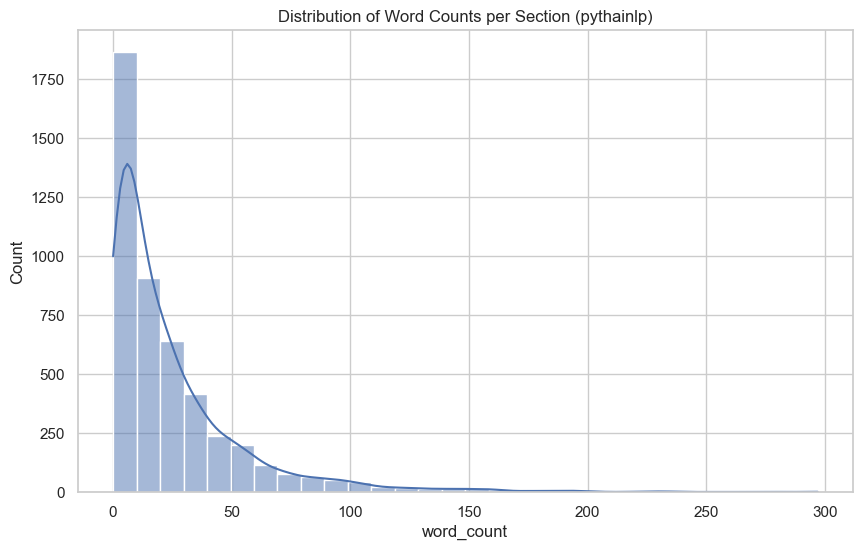

In [12]:
sample_text = df['text'].iloc[0]

tokens_newmm = word_tokenize(sample_text, engine='newmm')
tokens_attacut = word_tokenize(sample_text, engine='attacut')

print(f'Newmm Token Count: {len(tokens_newmm)}')
print(f'Attacut Token Count: {len(tokens_attacut)}')
print('Newmm Samples:', tokens_newmm[:10])
print('Attacut Samples:', tokens_attacut[:10])

stopwords = set(thai_stopwords())

def preprocess_thai(text):
    # tokenize
    tokens = word_tokenize(text, engine='attacut')

    clean_tokens = []
    for t in tokens:
        t = t.strip()
        # skip empty, stopwords, and punctuation
        if (
            t and
            t not in stopwords and
            not re.match(r'^[\W_]+$', t)  # removes punctuation/symbols
        ):
            clean_tokens.append(t)

    return clean_tokens

df['tokens'] = df['text'].progress_apply(preprocess_thai)
df['word_count'] = df['tokens'].dropna().apply(len)

# Visualize Word Counts
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'].dropna(), bins=30, kde=True)
plt.title('Distribution of Word Counts per Section (pythainlp)')
plt.show()

In [13]:
df.to_csv("../data/preprocessed_data.csv", index=False)